In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
import scanpy as sc
import anndata as ad


In [2]:
# !wget https://ftp.ncbi.nlm.nih.gov/geo/series/GSE224nnn/GSE224090/suppl/GSE224090%5FRAW%2Etar # Downloading the data using the hyperlink
# !tar -xvf GSE224090_RAW.tar # decompressing file
!ls

GSE224090_RAW.tar
GSM7011673_NU02954_PBMC.filtered_feature_bc_matrix.h5
GSM7011674_NU02954_Tumor.filtered_feature_bc_matrix.h5
GSM7011675_NU03014_PBMC.filtered_feature_bc_matrix.h5
GSM7011676_NU03014_Tumor.filtered_feature_bc_matrix.h5
HW2.ipynb
HW2_version_2.ipynb
HW2_version_3.ipynb
adata_combined_processed.h5ad


# Standard preprocessing

In [3]:
# Loadind AnnData (four objects)

NU02954_PBMC = sc.read_10x_h5('GSM7011673_NU02954_PBMC.filtered_feature_bc_matrix.h5')
NU02954_PBMC.var_names_make_unique()

NU02954_Tumor = sc.read_10x_h5('GSM7011674_NU02954_Tumor.filtered_feature_bc_matrix.h5')
NU02954_Tumor.var_names_make_unique()

NU03014_PBMC = sc.read_10x_h5('GSM7011675_NU03014_PBMC.filtered_feature_bc_matrix.h5')
NU03014_PBMC.var_names_make_unique()

NU03014_Tumor = sc.read_10x_h5('GSM7011676_NU03014_Tumor.filtered_feature_bc_matrix.h5')
NU03014_Tumor.var_names_make_unique()

/Users/chloesavignac/.conda/envs/bmde_python/lib/python3.14/site-packages/scanpy/readwrite.py:248: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata = adata.copy()
/Users/chloesavignac/.conda/envs/bmde_python/lib/python3.14/site-packages/scanpy/readwrite.py:248: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata = adata.copy()
/Users/chloesavignac/.conda/envs/bmde_python/lib/python3.14/site-packages/scanpy/readwrite.py:248: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata = adata.copy()
/Users/chloesavignac/.conda/envs/bmde_python/lib/python3.14/site-packages/scanpy/readwrite.py:248: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata = adata.copy()


In [4]:
NU02954_PBMC # looking at object (using one object for the manual inspection)

AnnData object with n_obs × n_vars = 8837 × 36601
    var: 'gene_ids', 'feature_types', 'genome'
    layers: None (.X)

In [5]:
NU02954_PBMC.X.max()

np.float32(12369.0)

In [6]:
NU02954_PBMC.var # 36601 genes

,gene_ids,feature_types,genome
MIR1302-2HG,ENSG00000243485,Gene Expression,GRCh38
FAM138A,ENSG00000237613,Gene Expression,GRCh38
OR4F5,ENSG00000186092,Gene Expression,GRCh38
AL627309.1,ENSG00000238009,Gene Expression,GRCh38
AL627309.3,ENSG00000239945,Gene Expression,GRCh38
...,...,...,...
AC141272.1,ENSG00000277836,Gene Expression,GRCh38
AC023491.2,ENSG00000278633,Gene Expression,GRCh38
AC007325.1,ENSG00000276017,Gene Expression,GRCh38
AC007325.4,ENSG00000278817,Gene Expression,GRCh38


In [7]:
NU02954_PBMC.obs # 8837 cells

""
AAACCTGAGAAACCGC-1
AAACCTGAGATGGCGT-1
AAACCTGAGATGTTAG-1
AAACCTGAGCCAGGAT-1
AAACCTGAGCTAAACA-1
...
TTTGTCAGTGTTTGTG-1
TTTGTCATCAGCTCGG-1
TTTGTCATCCACGCAG-1
TTTGTCATCCCGACTT-1


In [8]:
def preprocess_file(adata):
    """
    Perform basic quality control (QC) filtering on single-cell RNA-seq data.

    Filtering criteria:
        - Retain cells with at least 200 detected genes.
        - Retain genes detected in at least 3 cells.
        - Exclude cells with 2,500 or more detected genes (potential doublets).
        - Exclude cells with 5% or more mitochondrial counts (indicator of cellular damage or stress).

    Parameters
    ----------
    adata : anndata.AnnData
        Annotated single-cell gene expression matrix containing raw counts.
        Mitochondrial genes are expected to start with 'MT-'.

    Returns
    -------
    anndata.AnnData
        Filtered AnnData object with updated QC metrics.
    """

    print(f'{adata.n_obs} cells before QC')
    print('Verifying the object stored the raw counts.')
    print(f'Expression range: ({adata.X.min()}, {adata.X.max()})')

    # Filter cells and genes based on minimum detection thresholds
    sc.pp.filter_cells(adata, min_genes=200)
    sc.pp.filter_genes(adata, min_cells=3)

    print(f'Number of genes kept: {len(adata.var)}')

    # Exclude cells with unusually high numbers of detected genes
    # (potential doublets)
    adata = adata[adata.obs.n_genes < 2500, :].copy()

    print(f'{adata.n_obs} cells passed the first round of QC')

    # Identify mitochondrial genes
    adata.var['mt'] = adata.var_names.str.startswith('MT-')

    # Calculate QC metrics, including the percentage of mitochondrial counts
    sc.pp.calculate_qc_metrics(
        adata,
        qc_vars=['mt'],
        percent_top=None,
        log1p=False,
        inplace=True
    )

    # Exclude cells with high mitochondrial content
    adata = adata[adata.obs.pct_counts_mt < 5, :].copy()

    print(f'{adata.n_obs} cells remaining after mitochondrial filtering')

    # Inspection
    sc.pl.scatter(
        adata,
        x='total_counts',
        y='n_genes_by_counts',
        color='pct_counts_mt'
    )

    # divides the expression of each gene by the total counts detected in that cell
    sc.pp.normalize_total(adata, target_sum=1e4) # multiplies the result by 10,000
    sc.pp.log1p(adata) # log-normalization (most genes have low expression, the distribution is skewed)

    return adata


### NU02954_PBMC

8837 cells before QC
Verifying the object stored the raw counts.
Expression range: (0.0, 12369.0)
Number of genes kept: 17675
8488 cells passed the first round of QC
8155 cells remaining after mitochondrial filtering


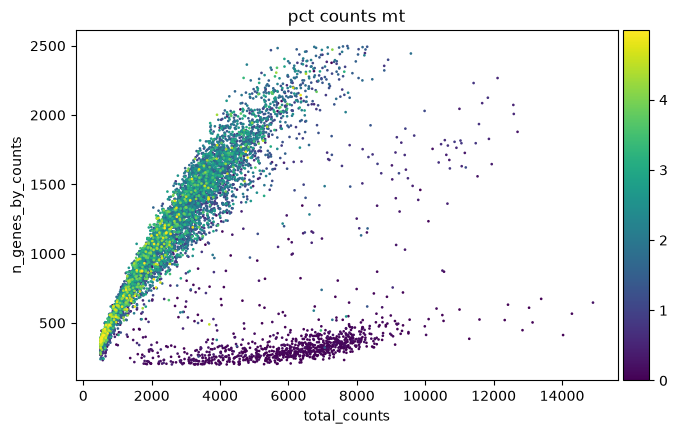

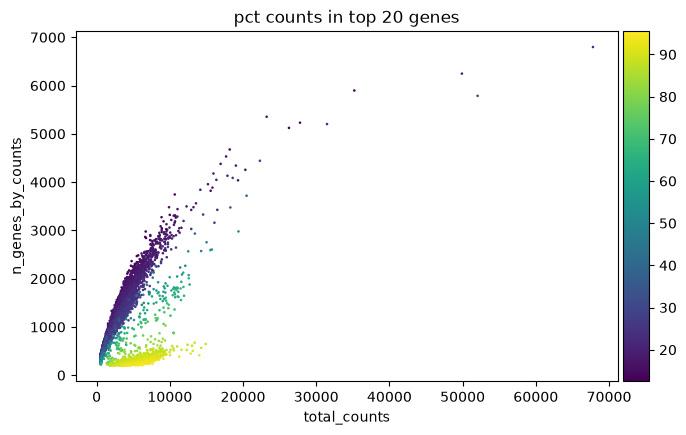

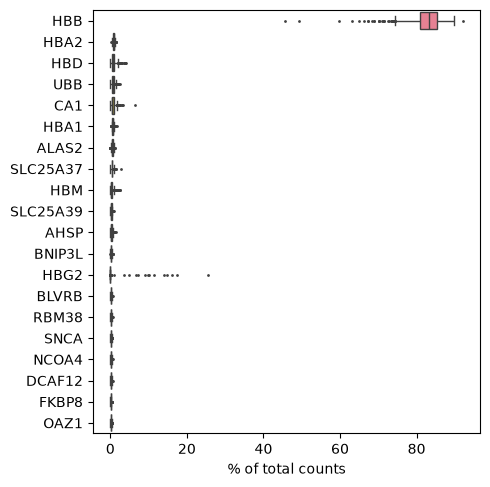

In [9]:
preprocess_file(NU02954_PBMC) 

# There is an anomaly here... cells with high total counts, but low_genes_by counts (dark population in first plot below)

NU02954_PBMC.var['mt'] = NU02954_PBMC.var_names.str.startswith('MT-')

sc.pp.calculate_qc_metrics(
    NU02954_PBMC,
    qc_vars=['mt'],
    percent_top=[10, 20, 50],
    log1p=False,
    inplace=True
)

sc.pl.scatter(
    NU02954_PBMC,
    x='total_counts',
    y='n_genes_by_counts',
    color='pct_counts_in_top_20_genes'
)

# Identify cells with high counts but low gene complexity
suspicious_cells = NU02954_PBMC[
    (NU02954_PBMC.obs.total_counts > 3000) &
    (NU02954_PBMC.obs.n_genes_by_counts < 600)
].copy()

# Identify their most highly expressed genes
sc.pl.highest_expr_genes(
    suspicious_cells,
    n_top=20
)


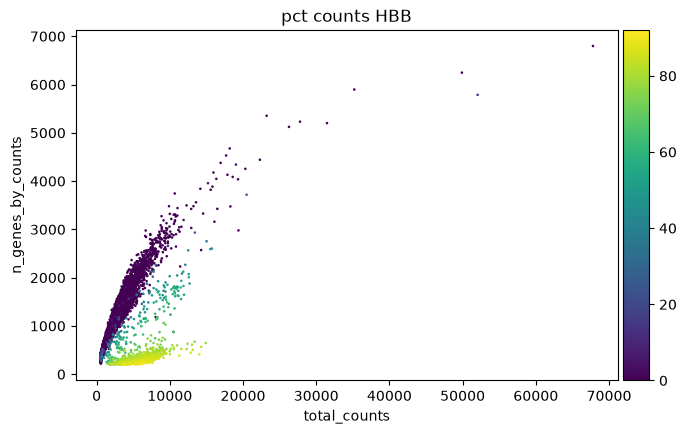

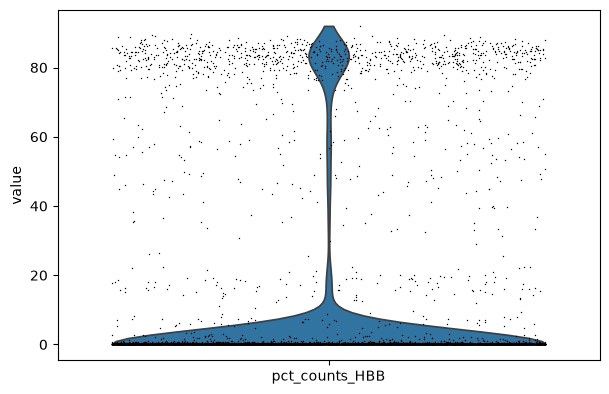

In [10]:
# HBB accounts for approximately 80–85% of total counts in many of the cells in the NU02954_PBMC sample 
# These are erythrocyte-associated markers

adata = NU02954_PBMC.copy()

# Calculate HBB percentage per cell
hbb = adata[:, 'HBB'].X

if hasattr(hbb, 'toarray'):
    hbb = hbb.toarray()

hbb = np.asarray(hbb).flatten()

total_counts = np.asarray(adata.X.sum(axis=1)).flatten()

adata.obs['pct_counts_HBB'] = np.divide(
    hbb,
    total_counts,
    out=np.zeros_like(hbb, dtype=float),
    where=total_counts > 0
) * 100

# Visualize
sc.pl.scatter(
    adata,
    x='total_counts',
    y='n_genes_by_counts',
    color='pct_counts_HBB',
    color_map='viridis'
)

sc.pl.violin(
    adata,
    keys=['pct_counts_HBB'],
    jitter=0.4
)

# additional filtering for that cell type based on the extra QC steps:

NU02954_PBMC = adata[adata.obs.pct_counts_HBB < 30, :].copy()

7586 cells before QC
Verifying the object stored the raw counts.
Expression range: (0.0, 7539.0)
Number of genes kept: 17532
7412 cells passed the first round of QC
7081 cells remaining after mitochondrial filtering


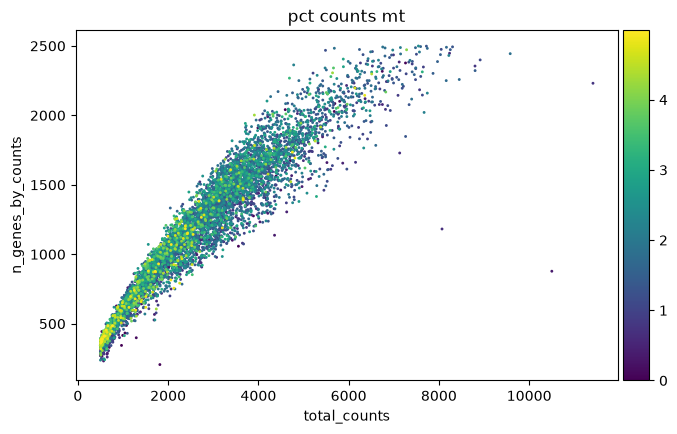

7525 cells before QC
Verifying the object stored the raw counts.
Expression range: (0.0, 3085.0)
Number of genes kept: 17326
7410 cells passed the first round of QC
7079 cells remaining after mitochondrial filtering


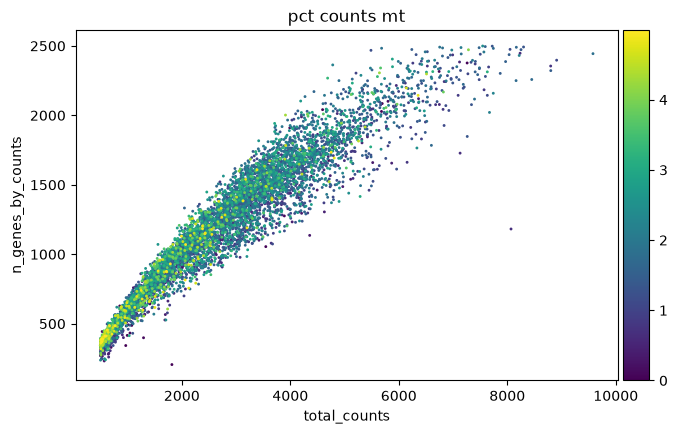

7525 cells before QC
Verifying the object stored the raw counts.
Expression range: (0.0, 3085.0)
Number of genes kept: 17326
7410 cells passed the first round of QC
7079 cells remaining after mitochondrial filtering


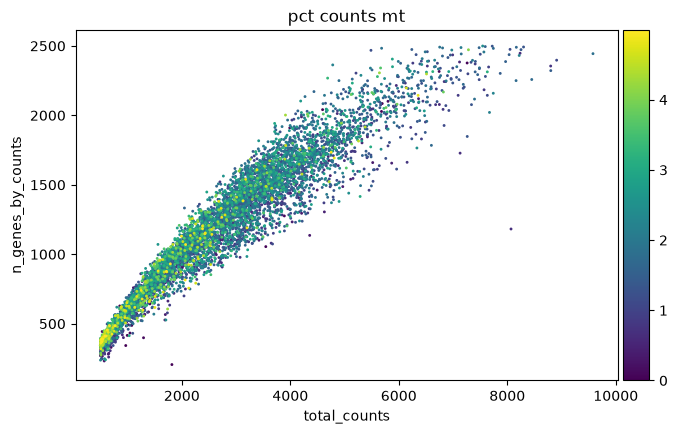

In [11]:
preprocess_file(NU02954_PBMC) # 7081 cells

preprocess_file(NU02954_PBMC[NU02954_PBMC.obs.total_counts <= 10000, :].copy()) # two cells difference --> 7079 cells

NU02954_PBMC_proccessed = preprocess_file(NU02954_PBMC[NU02954_PBMC.obs.total_counts <= 10000, :].copy())

### NU02954_Tumor

9238 cells before QC
Verifying the object stored the raw counts.
Expression range: (0.0, 2357.0)
Number of genes kept: 19780
8854 cells passed the first round of QC
8587 cells remaining after mitochondrial filtering


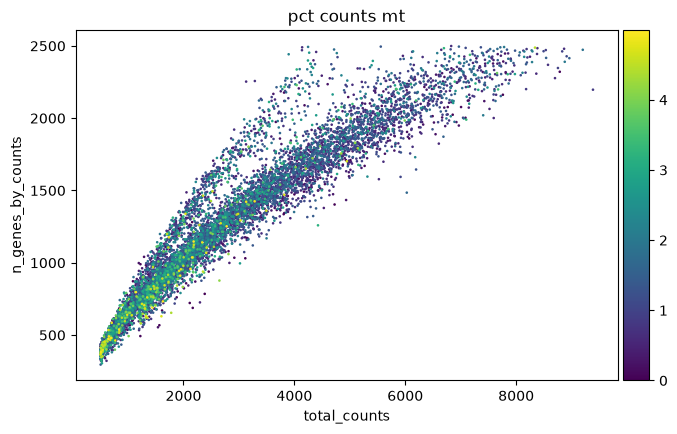

9237 cells before QC
Verifying the object stored the raw counts.
Expression range: (0.0, 2357.0)
Number of genes kept: 19780
8854 cells passed the first round of QC
8587 cells remaining after mitochondrial filtering


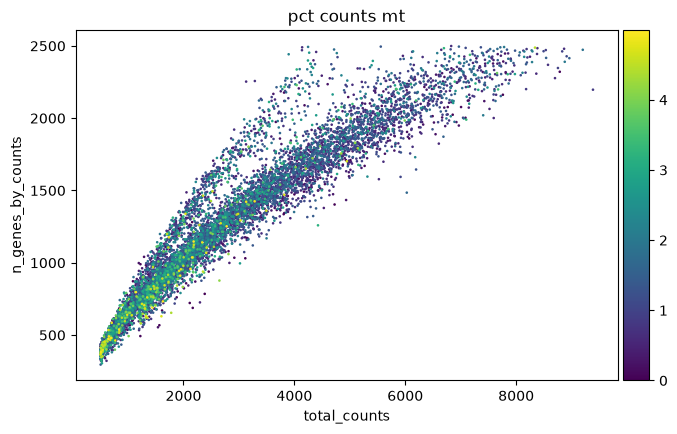

In [ ]:
preprocess_file(NU02954_Tumor) # Looks good! There are two curves but they could be different cell types...

NU02954_Tumor_processed = preprocess_file(NU02954_Tumor)

### NU03014_PBMC

In [13]:
NU03014_PBMC

AnnData object with n_obs × n_vars = 10484 × 36601
    var: 'gene_ids', 'feature_types', 'genome'
    layers: None (.X)

10484 cells before QC
Verifying the object stored the raw counts.
Expression range: (0.0, 13303.0)
Number of genes kept: 20681
7985 cells passed the first round of QC
7493 cells remaining after mitochondrial filtering


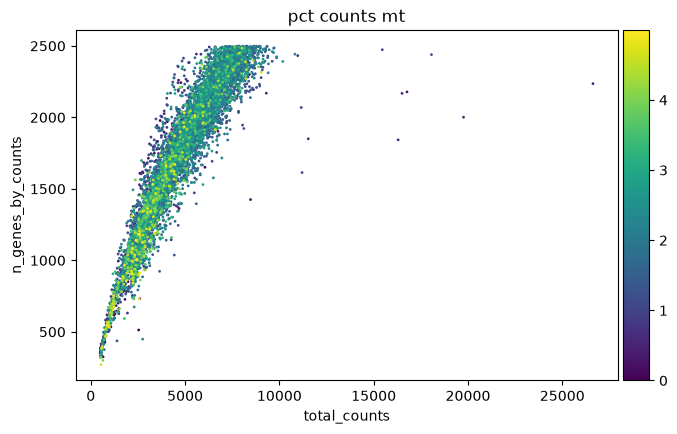

9311 cells before QC
Verifying the object stored the raw counts.
Expression range: (0.0, 2334.0)
Number of genes kept: 19847
7973 cells passed the first round of QC
7481 cells remaining after mitochondrial filtering


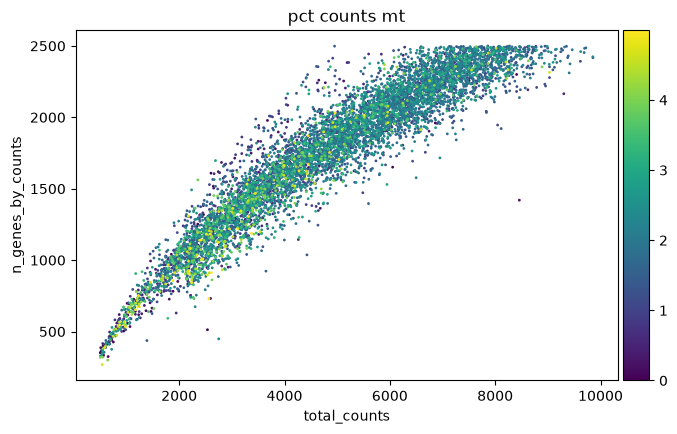

9311 cells before QC
Verifying the object stored the raw counts.
Expression range: (0.0, 2334.0)
Number of genes kept: 19847
7973 cells passed the first round of QC
7481 cells remaining after mitochondrial filtering


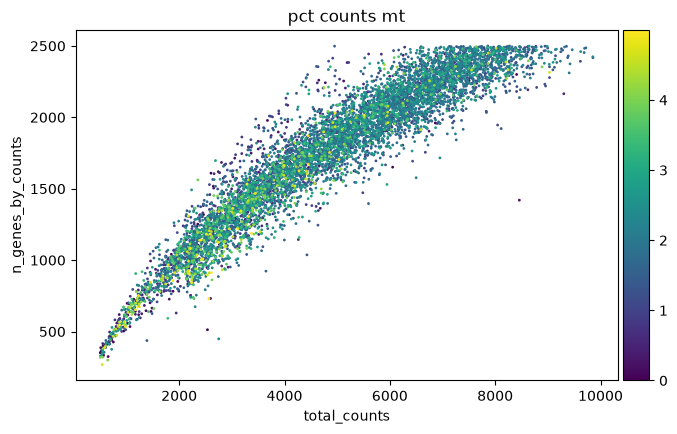

In [14]:
preprocess_file(NU03014_PBMC)

sc.pp.calculate_qc_metrics(
    NU03014_PBMC,
    percent_top=None,
    log1p=False,
    inplace=True
)

preprocess_file(NU03014_PBMC[NU03014_PBMC.obs.total_counts <= 10000, :].copy()) # Looks much better! 13 outliers excluded 

NU03014_PBMC_processed = preprocess_file(NU03014_PBMC[NU03014_PBMC.obs.total_counts <= 10000, :].copy())


### NU03014_Tumor

11710 cells before QC
Verifying the object stored the raw counts.
Expression range: (0.0, 13160.0)
Number of genes kept: 18826
11147 cells passed the first round of QC
10944 cells remaining after mitochondrial filtering


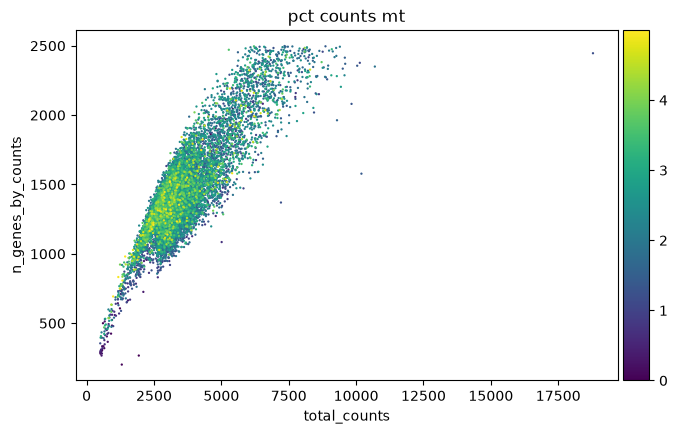

11432 cells before QC
Verifying the object stored the raw counts.
Expression range: (0.0, 3607.0)
Number of genes kept: 18522
11142 cells passed the first round of QC
10940 cells remaining after mitochondrial filtering


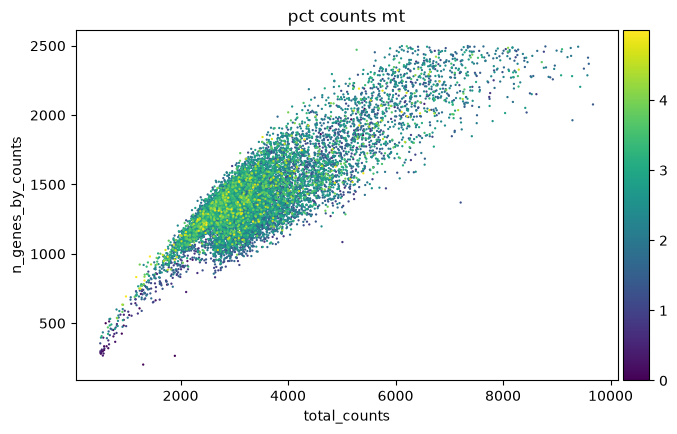

11432 cells before QC
Verifying the object stored the raw counts.
Expression range: (0.0, 3607.0)
Number of genes kept: 18522
11142 cells passed the first round of QC
10940 cells remaining after mitochondrial filtering


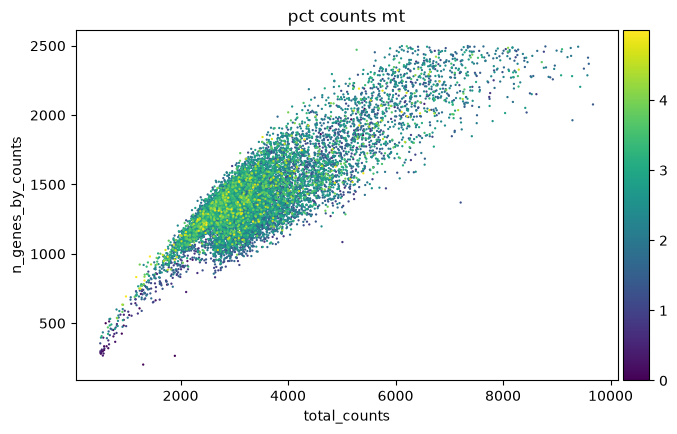

In [15]:
preprocess_file(NU03014_Tumor)

sc.pp.calculate_qc_metrics(
    NU03014_Tumor,
    percent_top=None,
    log1p=False,
    inplace=True
)

preprocess_file(NU03014_Tumor[NU03014_Tumor.obs.total_counts <= 10000, :].copy()) # Looks much better! 4 outliers excluded 

NU03014_Tumor_processed = preprocess_file(NU03014_Tumor[NU03014_Tumor.obs.total_counts <= 10000, :].copy())

# Integration

In [ ]:
# Verifying that the stored counts are log-normalized 
NU02954_PBMC_proccessed.X.max(), NU02954_Tumor_processed.X.max(), NU03014_PBMC_processed.X.max(), NU03014_Tumor_processed.X.max()

(np.float32(8.249124),
 np.float32(7.879083),
 np.float32(8.410845),
 np.float32(8.912782))

In [24]:
# before integration, let's look at the number of overlapping genes

datasets = {
    'NU02954_PBMC': NU02954_PBMC_proccessed,
    'NU02954_Tumor': NU02954_Tumor_processed,
    'NU03014_PBMC': NU03014_PBMC_processed,
    'NU03014_Tumor': NU03014_Tumor_processed
}

for name, adata in datasets.items():
    print(f'{name}: {adata.n_obs} cells × {adata.n_vars} genes')

gene_sets = [set(adata.var_names) for adata in datasets.values()]

shared_genes = set.intersection(*gene_sets)
all_genes = set.union(*gene_sets)

print(f'Genes shared across all datasets: {len(shared_genes)}')
print(f'Total unique genes: {len(all_genes)}')

NU02954_PBMC: 7079 cells × 17326 genes
NU02954_Tumor: 8587 cells × 19780 genes
NU03014_PBMC: 7481 cells × 19847 genes
NU03014_Tumor: 10940 cells × 18522 genes
Genes shared across all datasets: 15392
Total unique genes: 22743


In [25]:
# Integrating datasets
adata_combined = ad.concat(
    [NU02954_PBMC_proccessed, NU02954_Tumor_processed, NU03014_PBMC_processed, NU03014_Tumor_processed],
    axis=0,
    join='inner',
    label='batch',
    keys=['NU02954_PBMC', 'NU02954_Tumor', 'NU03014_PBMC', 'NU03014_Tumor'],
    index_unique='-'
)

# Extract patient and tissue information
adata_combined.obs['patient'] = (
    adata_combined.obs['batch'].str.split('_').str[0]
)

adata_combined.obs['tissue'] = (
    adata_combined.obs['batch'].str.split('_').str[1]
)

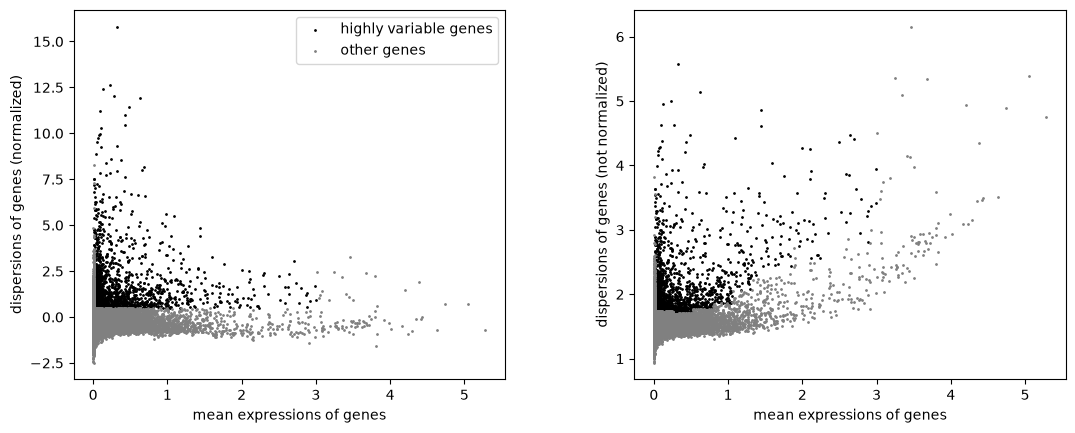

In [ ]:
sc.pp.highly_variable_genes(adata_combined, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pl.highly_variable_genes(adata_combined)

# A negative value indicates that a gene is less variable than expected relative to genes with comparable mean expression.

In [27]:
adata_combined_HVGs = adata_combined[:, adata_combined.var.highly_variable].copy() 

## Exploration

In [28]:
adata_combined_HVGs

AnnData object with n_obs × n_vars = 34087 × 1988
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'batch', 'patient', 'tissue'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg'
    layers: None (.X)

In [29]:
top_genes = (
    adata_combined.var
    .loc[adata_combined.var.highly_variable]
    .sort_values('dispersions_norm', ascending=False)
    .head(100)
    .index
    .tolist()
)

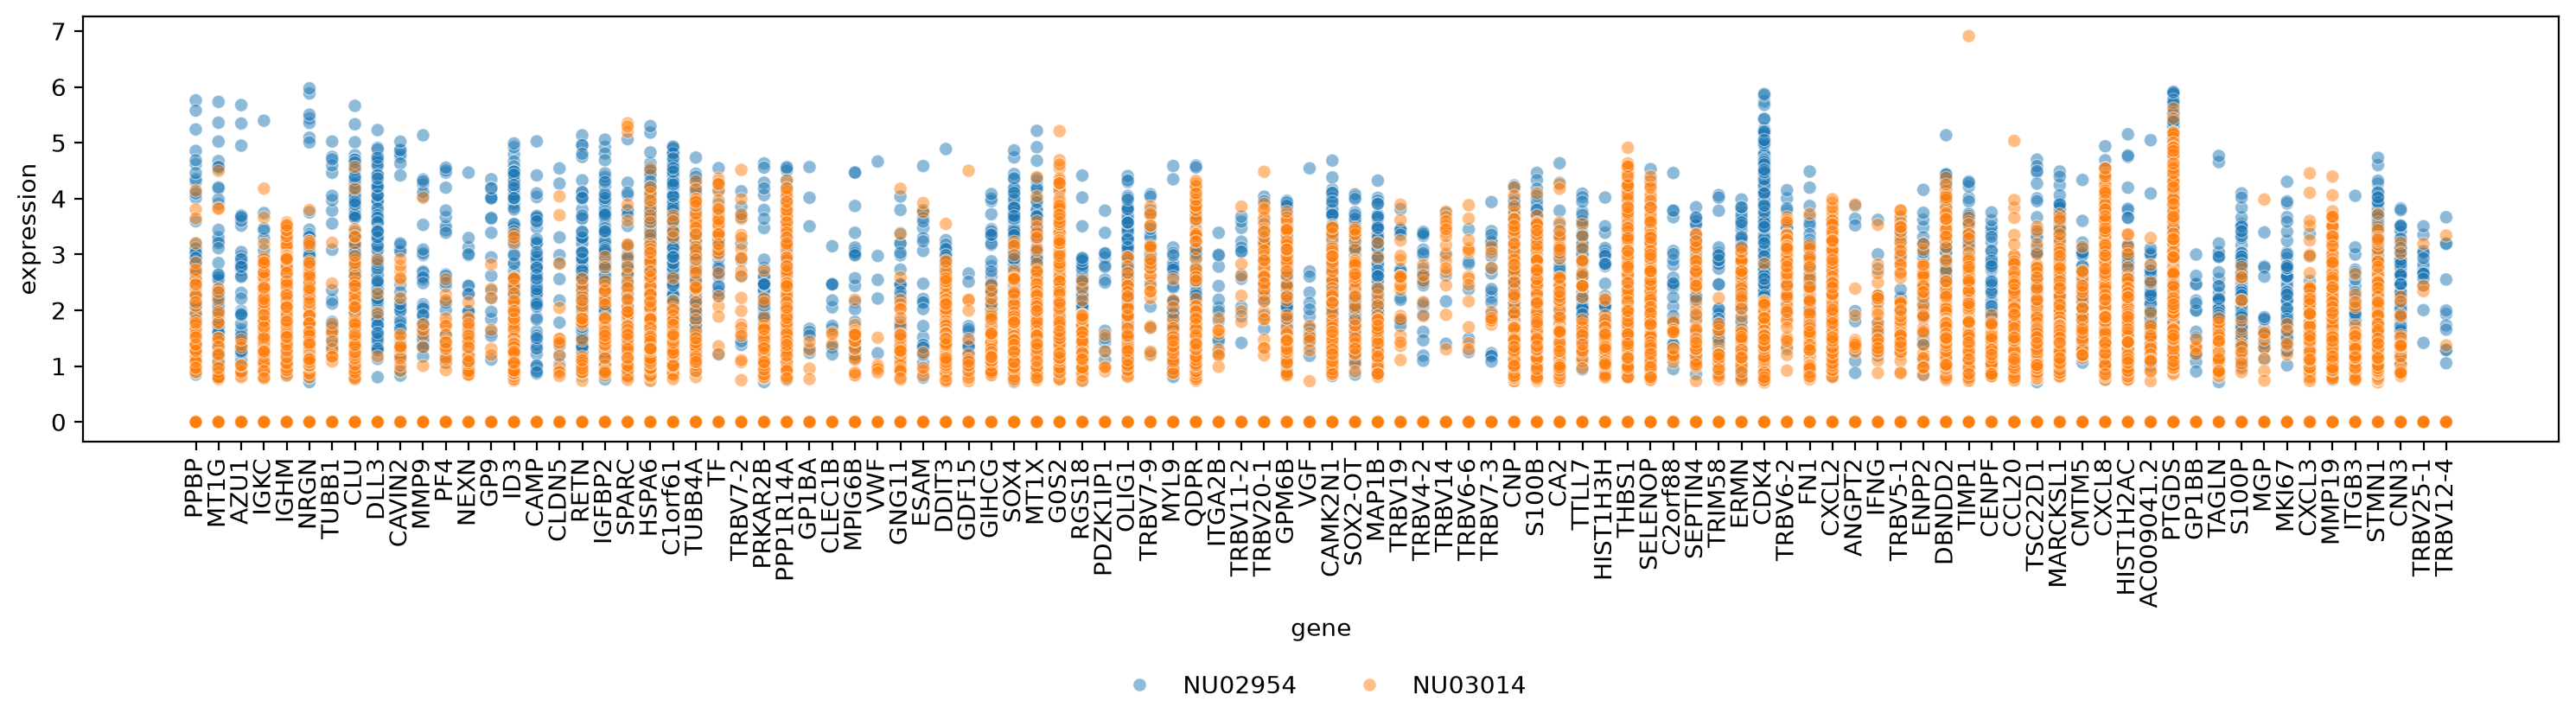

In [30]:
n = 2000  # Number of cells per patient–tissue combination

to_plot = adata_combined[:, top_genes].copy()

# Randomly sample n cells per patient and tissue (to facilitate visualization)
sampled_obs = (
    to_plot.obs
    .groupby(['patient', 'tissue'], observed=True, group_keys=False)
    .sample(n=n, random_state=42)
)

# Subset AnnData
to_plot = to_plot[sampled_obs.index, :].copy()

# Convert expression matrix to DataFrame
df = pd.DataFrame(
    to_plot.X.toarray(),
    columns=top_genes
)

# Add metadata
df['patient'] = to_plot.obs.patient.values
df['tissue'] = to_plot.obs.tissue.values

# Convert to long format
df_long = df.melt(
    id_vars=['patient', 'tissue'],
    var_name='gene',
    value_name='expression'
)

# Preserve HVG ranking
df_long['gene'] = pd.Categorical(
    df_long['gene'],
    categories=top_genes,
    ordered=True
)

# Plot

plt.figure(figsize=(15,5), dpi=200)

sns.scatterplot(
    data=df_long,
    x='gene',
    y='expression',
    hue='patient',
    # style='tissue',
    alpha=0.5,
    s=30,
    # legend=False,
)

plt.xticks(rotation=90)

# Move legend below the plot
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.5),
    ncol=4,
    frameon=False
)

plt.tight_layout()
plt.show()
plt.close('all')

The plot above shows that in general, gene expression is higher in NU02954 than in NU03014. This should be taken into account when writing the results. 

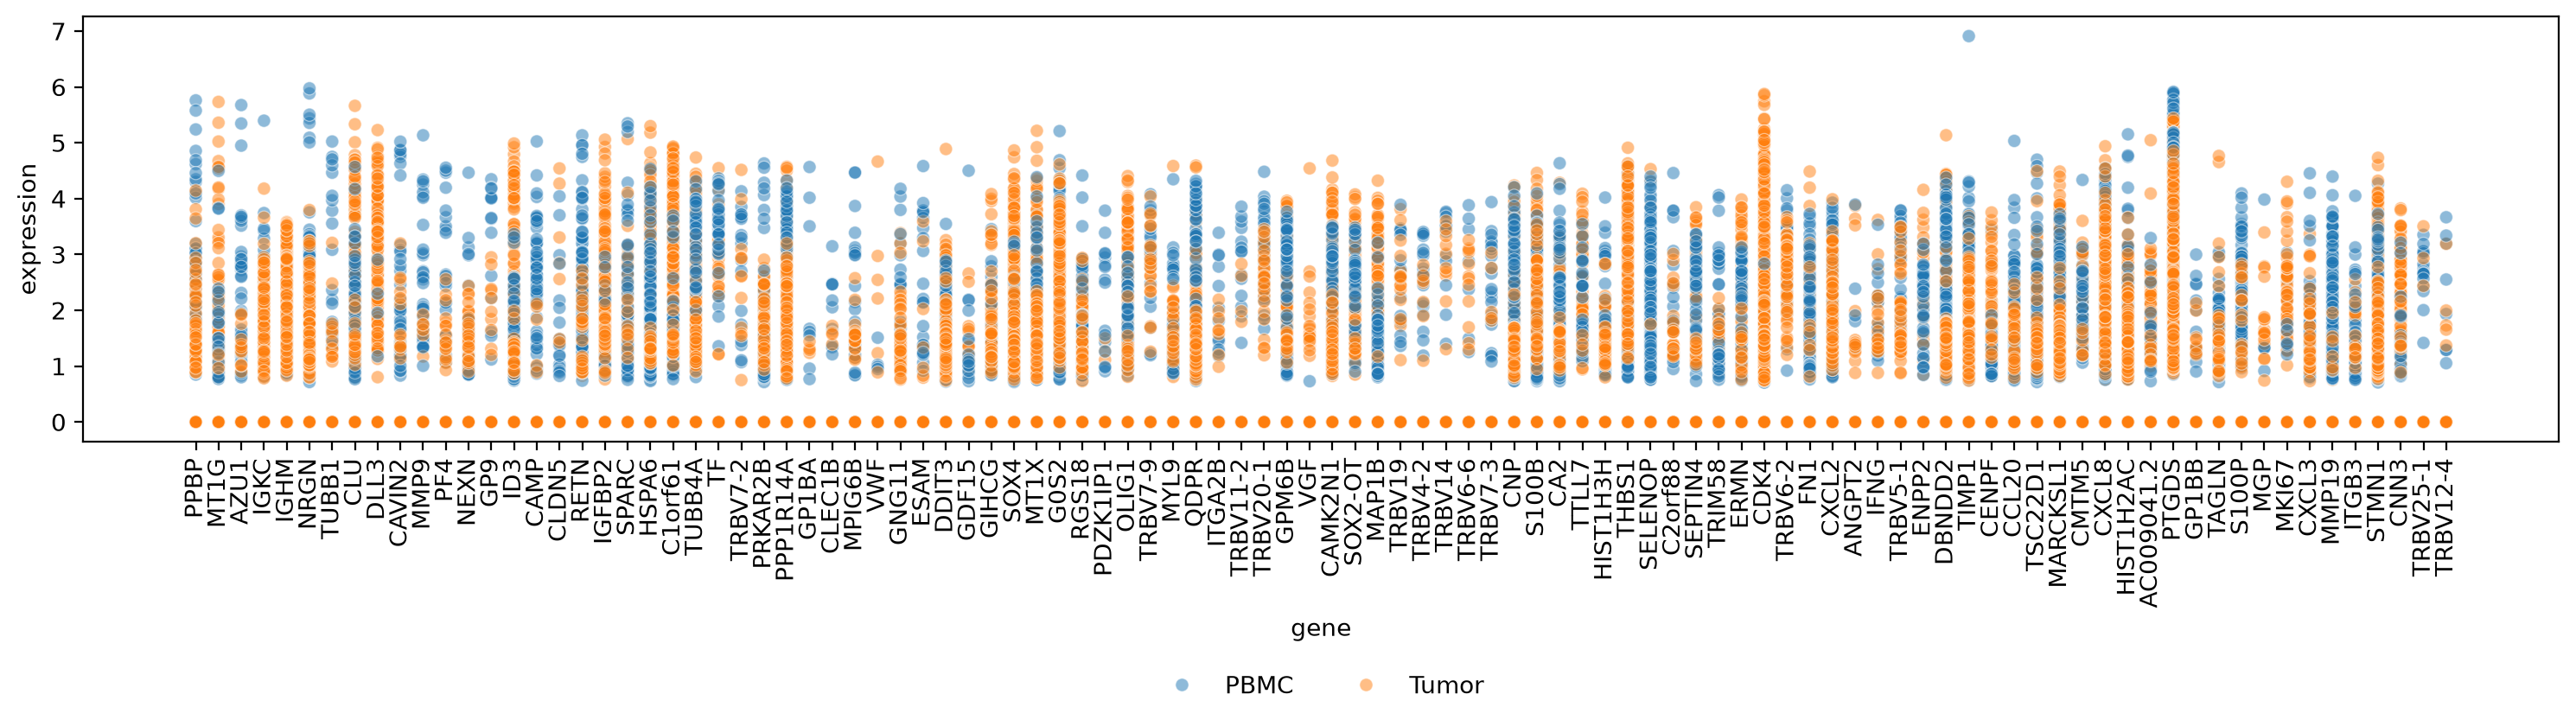

In [31]:
n = 2000  # Number of cells per patient–tissue combination

to_plot = adata_combined[:, top_genes].copy()

# Randomly sample n cells per patient and tissue (to facilitate visualization)
sampled_obs = (
    to_plot.obs
    .groupby(['patient', 'tissue'], observed=True, group_keys=False)
    .sample(n=n, random_state=42)
)

# Subset AnnData
to_plot = to_plot[sampled_obs.index, :].copy()

# Convert expression matrix to DataFrame
df = pd.DataFrame(
    to_plot.X.toarray(),
    columns=top_genes
)

# Add metadata
df['patient'] = to_plot.obs.patient.values
df['tissue'] = to_plot.obs.tissue.values

# Convert to long format
df_long = df.melt(
    id_vars=['patient', 'tissue'],
    var_name='gene',
    value_name='expression'
)

# Preserve HVG ranking
df_long['gene'] = pd.Categorical(
    df_long['gene'],
    categories=top_genes,
    ordered=True
)

# Plot

plt.figure(figsize=(15,5), dpi=200)

sns.scatterplot(
    data=df_long,
    x='gene',
    y='expression',
    hue='tissue',
    # style='tissue',
    alpha=0.5,
    s=30,
    # legend=False,
)

plt.xticks(rotation=90)

# Move legend below the plot
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.5),
    ncol=4,
    frameon=False
)

plt.tight_layout()
plt.show()
plt.close('all')

Right away, we can see that CDK4 is highly expressed in Tumor cells. This makes sense, as this gene plays a key role in tumorigenesis (Baker et al., 2012). 


Baker SJ, Reddy EP. CDK4: A Key Player in the Cell Cycle, Development, and Cancer: A Key Player in the Cell Cycle, Development, and Cancer. Genes & Cancer. 2012;3(11-12):658-669. doi:10.1177/1947601913478972
  

# Dimensionality reduction

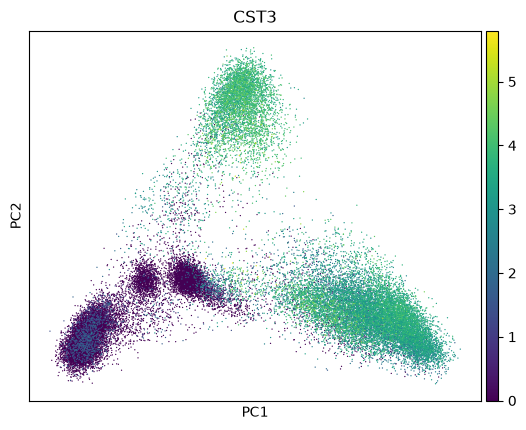

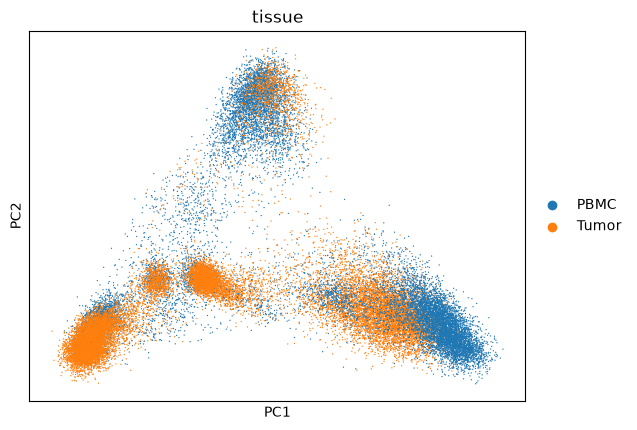

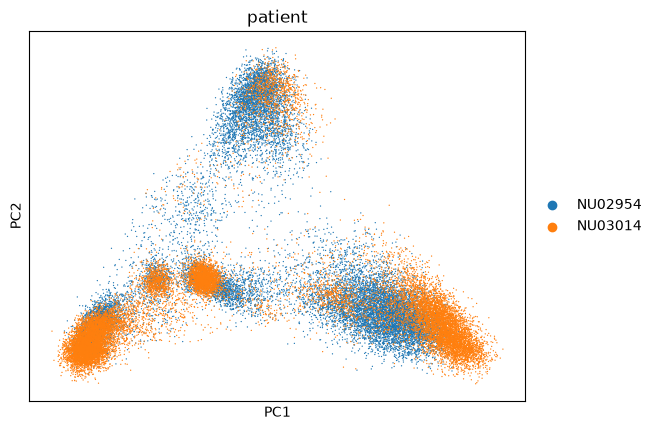

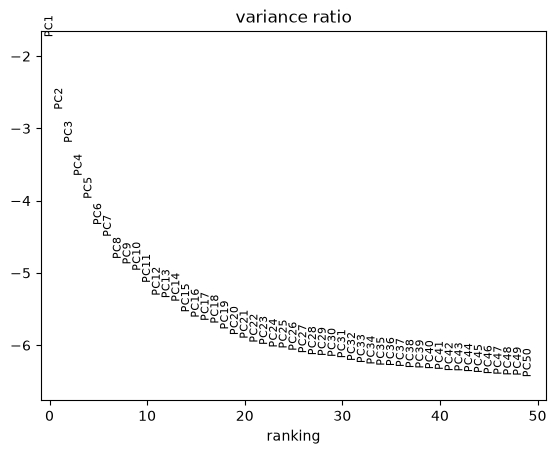

In [33]:
sc.tl.pca(adata_combined_HVGs, svd_solver='arpack') # using only the HVGs 

# Plot first two principal components (PCs)
sc.pl.pca(adata_combined_HVGs, color='CST3') # color with CST3 (a marker of monocytes)

sc.pl.pca(adata_combined_HVGs, color='tissue') # color by tissue type

sc.pl.pca(adata_combined_HVGs, color='patient') # color by patient

# look at the variance ratio of the PCs
sc.pl.pca_variance_ratio(
    adata_combined_HVGs,
    n_pcs=50,
    log=True
)

/var/folders/pr/cb_pqkw930d_pggjvtvfzl3w0000gn/T/ipykernel_34274/1210710148.py:8: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_combined_HVGs)


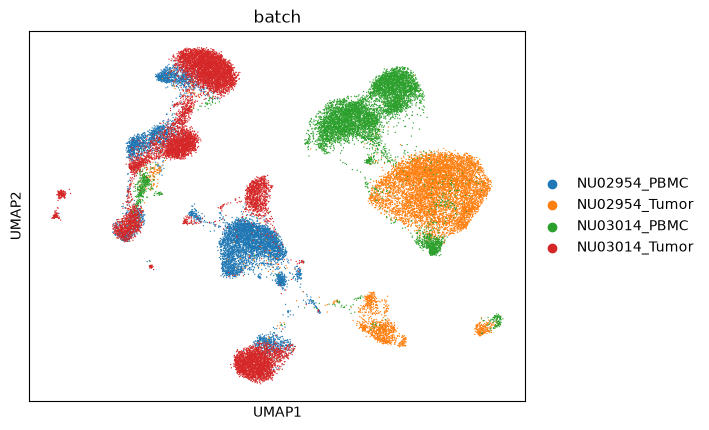

In [ ]:
# Let's build a KNN graph using the PCs scores as features
sc.pp.neighbors(adata_combined_HVGs, n_neighbors=15, n_pcs=50) # using all PCs, default neighbour values 

# Based on the KNN graph, let's run a UMAP
sc.tl.umap(adata_combined_HVGs) # using the default umap parameters 

# We will find clusters of cells that vary together
sc.tl.leiden(adata_combined_HVGs)

sc.pl.umap(adata_combined_HVGs, color=['batch'])

/var/folders/pr/cb_pqkw930d_pggjvtvfzl3w0000gn/T/ipykernel_34274/888600207.py:8: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_combined_HVGs)


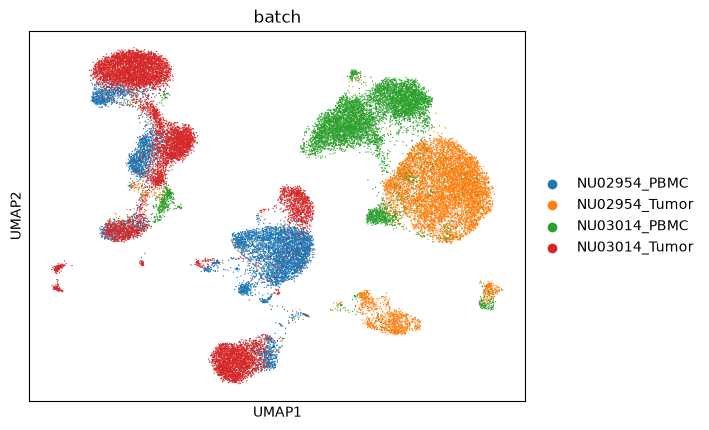

In [ ]:
# Let's build a KNN graph using the PCs scores as features
sc.pp.neighbors(adata_combined_HVGs, n_neighbors=15, n_pcs=30) # using 30 PCs, default neighboor values 

# Based on the KNN graph, let's run a UMAP
sc.tl.umap(adata_combined_HVGs) # using the default umap parameters 

# We will find clusters of cells that vary together
sc.tl.leiden(adata_combined_HVGs)

sc.pl.umap(adata_combined_HVGs, color=['batch'])

/var/folders/pr/cb_pqkw930d_pggjvtvfzl3w0000gn/T/ipykernel_34274/3422811309.py:8: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_combined_HVGs)


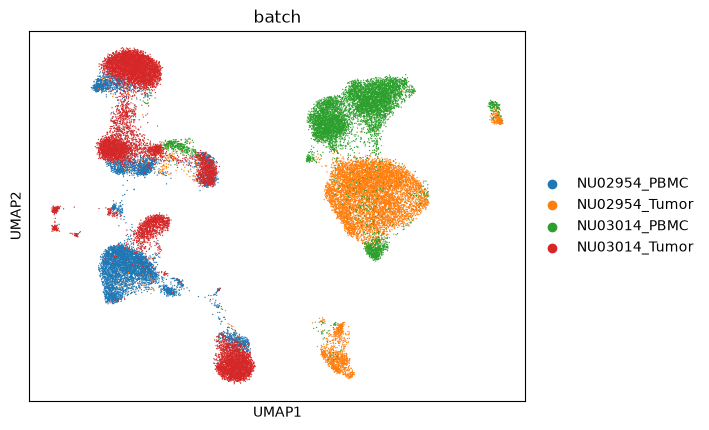

In [37]:
# Let's build a KNN graph using the PCs scores as features
sc.pp.neighbors(adata_combined_HVGs, n_neighbors=50, n_pcs=50) # using all PCs, 50 neighbours

# Based on the KNN graph, let's run a UMAP
sc.tl.umap(adata_combined_HVGs) # using the default umap parameters 

# We will find clusters of cells that vary together
sc.tl.leiden(adata_combined_HVGs)

sc.pl.umap(adata_combined_HVGs, color=['batch'])

/var/folders/pr/cb_pqkw930d_pggjvtvfzl3w0000gn/T/ipykernel_34274/984488191.py:8: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_combined_HVGs)


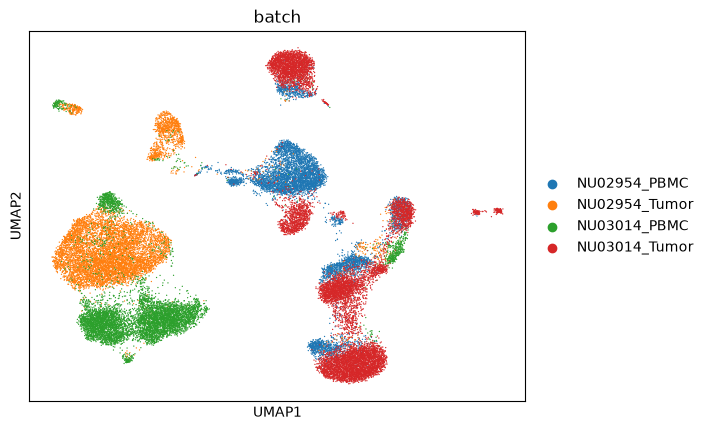

In [38]:
# Let's build a KNN graph using the PCs scores as features
sc.pp.neighbors(adata_combined_HVGs, n_neighbors=50, n_pcs=30) # using a30 PCs, 50 neighbours

# Based on the KNN graph, let's run a UMAP
sc.tl.umap(adata_combined_HVGs) # using the default umap parameters 

# We will find clusters of cells that vary together
sc.tl.leiden(adata_combined_HVGs)

sc.pl.umap(adata_combined_HVGs, color=['batch'])

The UMAP above looks good (patient and tissue type (tumor vs pmbc) well integrated)

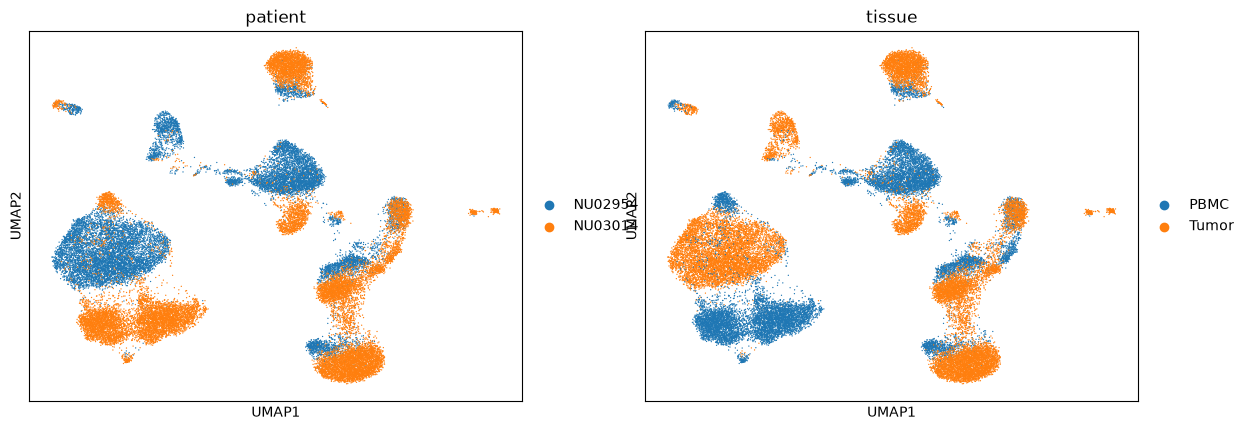

In [ ]:
sc.pl.umap(adata_combined_HVGs, color=['patient', 'tissue'])

All clusters have cells from both patients, and from both tumor and pbmc (suggesting that cells are probably clustered by cell type).

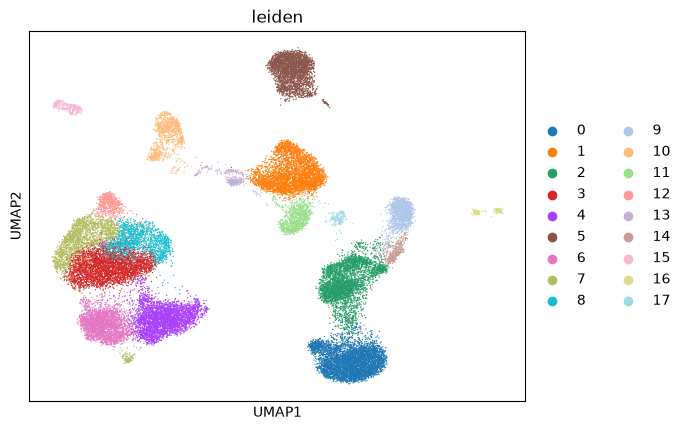

In [40]:
sc.pl.umap(adata_combined_HVGs, color=['leiden'])

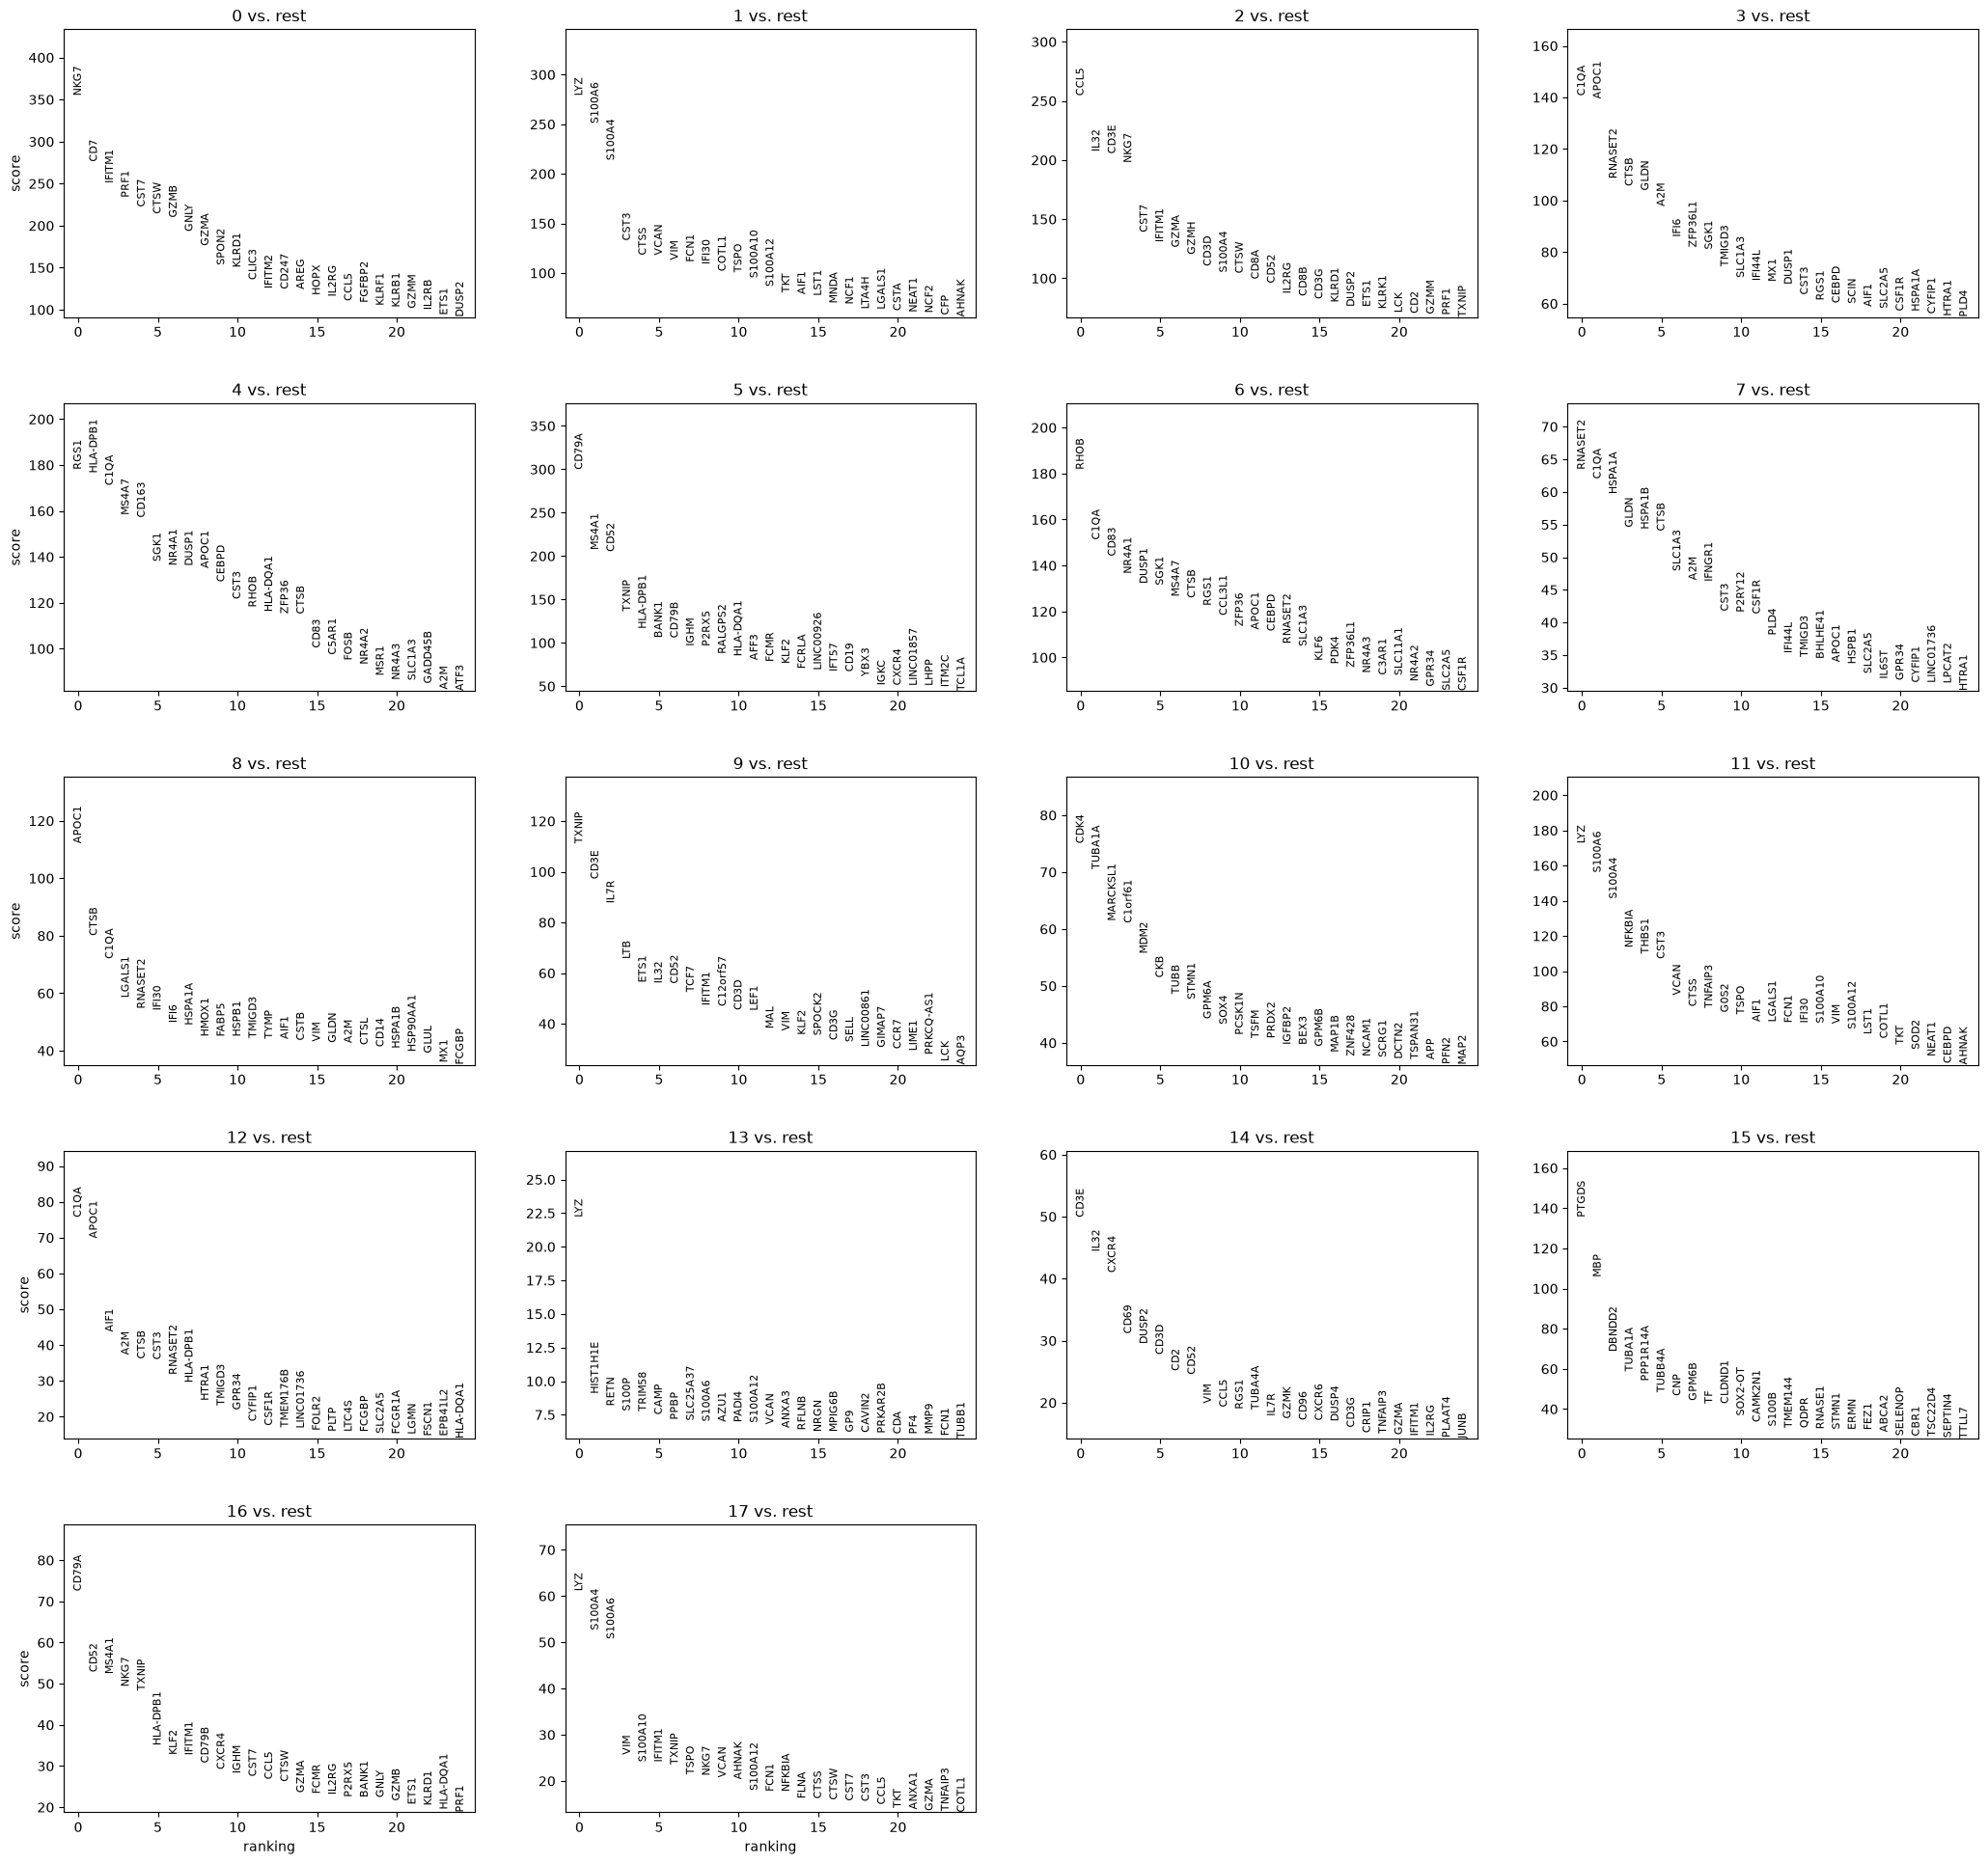

In [41]:
sc.tl.rank_genes_groups(adata_combined_HVGs, 'leiden', method='t-test')
sc.pl.rank_genes_groups(adata_combined_HVGs, n_genes=25, sharey=False)

In [42]:
adata_combined_HVGs.write_h5ad('adata_combined.h5ad')

# Cell type annotation

## Scanpy annotations

Reference : https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html

In [25]:
adata_processed = sc.read_h5ad('adata_combined.h5ad')

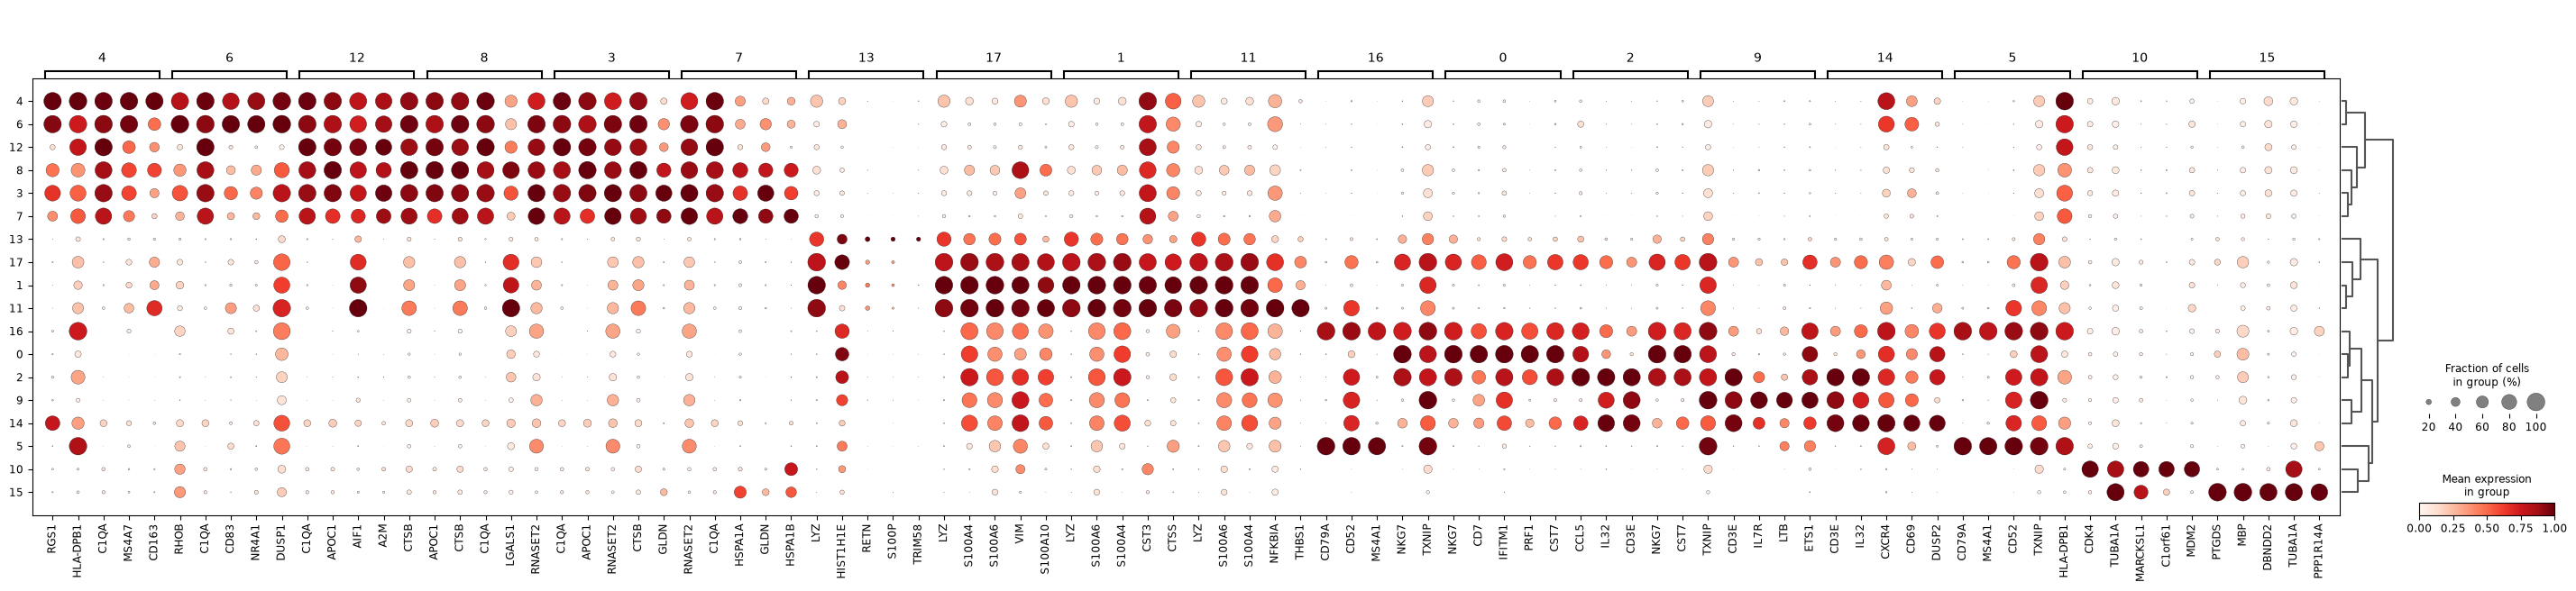

In [36]:
# Using the differently expressed genes
sc.pl.rank_genes_groups_dotplot(adata_processed, groupby="leiden", standard_scale="var", n_genes=5)

Markers are shared across subclusters, I will use a higher resolution for cell type annotations (see below)

In [40]:
for res in [0.02, 0.5, 2.0]:
    sc.tl.leiden(adata_processed, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

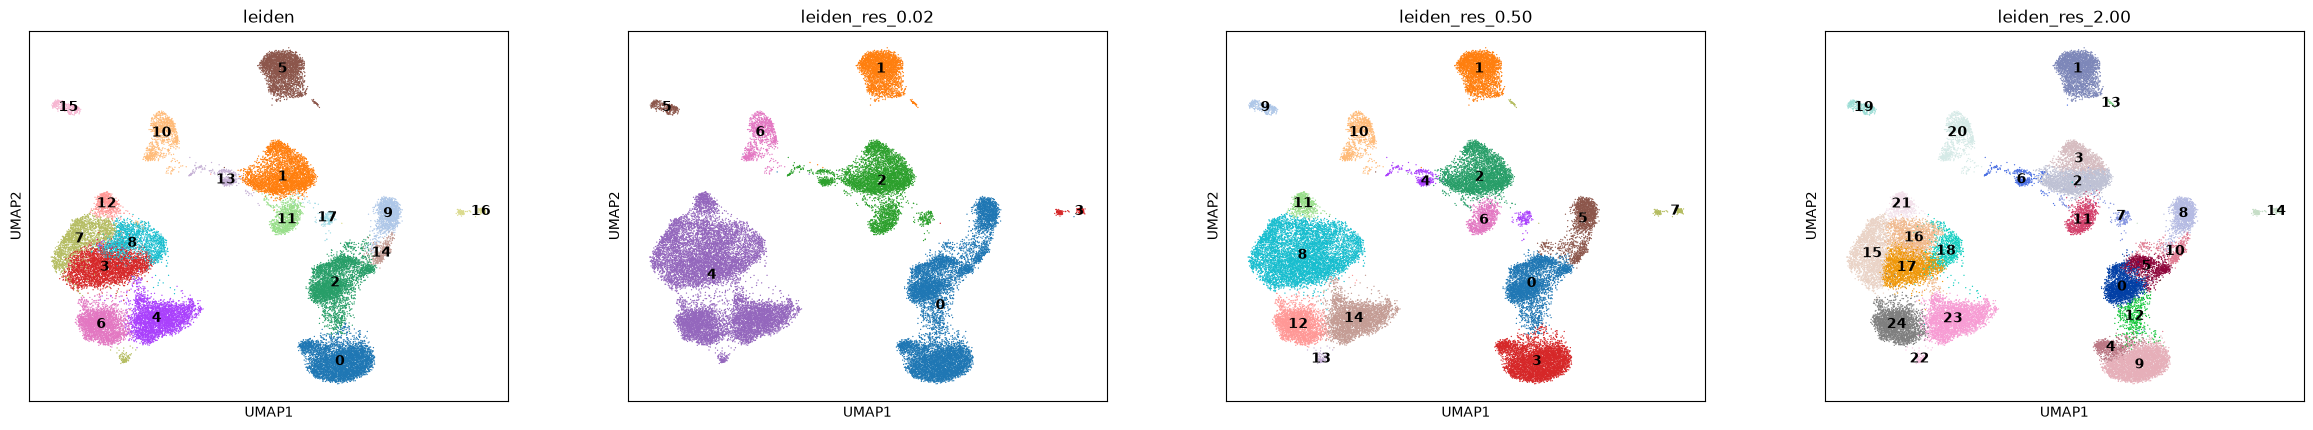

In [41]:
sc.pl.umap(
    adata_processed,
    color=["leiden", "leiden_res_0.02", "leiden_res_0.50", "leiden_res_2.00"], # comparing with default value
    legend_loc="on data",
)

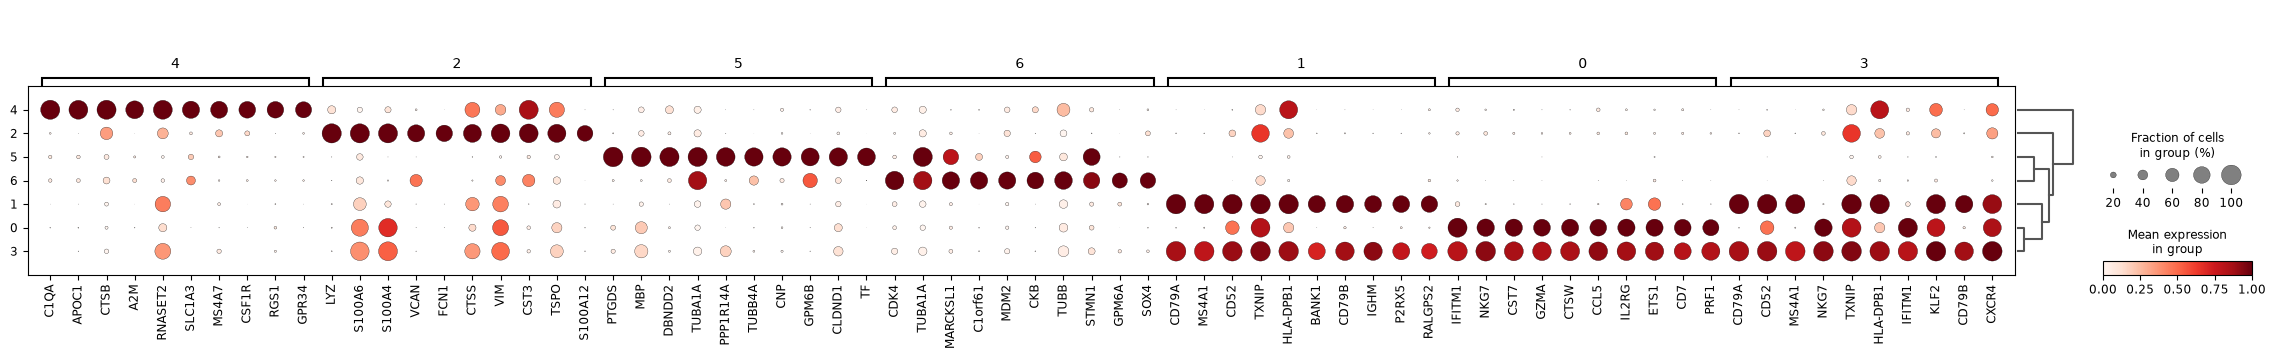

In [45]:
sc.tl.rank_genes_groups(adata_processed, groupby="leiden_res_0.02", method='t-test')

# Using the differently expressed genes
sc.pl.rank_genes_groups_dotplot(adata_processed, groupby="leiden_res_0.02", standard_scale="var", n_genes=10)

I used CellMarker 3.0 to derive cell type labels (https://bio-bigdata.hrbmu.edu.cn/CellMarker/#/tools/cell-annotation)

Cluster 4 --> Macrophage

Marker genes: 
4C1QA
APOC1
CTSB
A2M
RNASET2
SLC1A3
MS4A7
CSF1R
RGS1
GPR34

Cluster 2 --> 

Cluster 5 -->

Cluster 6 -->

Cluster 1 --> 

Cluster 0 -->

Cluster 3 --> 

## Automatic annotation (MapMyCells)

The datasets comprises gliobastomia (brain cancer)... Let's see what happens if using mapmycells whole-brain taxonomy as a reference atlas.

I am using MapMyCells: Cell Type Mapper

See here: https://github.com/AllenInstitute/cell_type_mapper/tree/main

This code provides a python package for mapping single sell RNA sequencing data onto a cell type taxonomy such as those provided by the Allen Institute for Brain Science. 

In [ ]:
# !wget https://allen-brain-cell-atlas.s3-us-west-2.amazonaws.com/mapmycells/WHB-10Xv3/20240831/precomputed_stats.siletti.training.h5

--2026-09-27 15:52:41--  https://allen-brain-cell-atlas.s3-us-west-2.amazonaws.com/mapmycells/WHB-10Xv3/20240831/precomputed_stats.siletti.training.h5
Resolving allen-brain-cell-atlas.s3-us-west-2.amazonaws.com (allen-brain-cell-atlas.s3-us-west-2.amazonaws.com)... 16.15.35.160, 3.5.87.118, 52.218.132.185, ...
Connecting to allen-brain-cell-atlas.s3-us-west-2.amazonaws.com (allen-brain-cell-atlas.s3-us-west-2.amazonaws.com)|16.15.35.160|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8724563136 (8.1G) [binary/octet-stream]
Saving to: ‘precomputed_stats.siletti.training.h5’

precomputed_stats.s 100%[===================>]   8.12G  38.1MB/s    in 3m 42s  

2026-09-27 15:56:23 (37.5 MB/s) - ‘precomputed_stats.siletti.training.h5’ saved [8724563136/8724563136]



In [ ]:
# !wget https://allen-brain-cell-atlas.s3-us-west-2.amazonaws.com/mapmycells/WHB-10Xv3/20240831/query_markers.n10.20240221800.json

--2026-09-27 15:56:33--  https://allen-brain-cell-atlas.s3-us-west-2.amazonaws.com/mapmycells/WHB-10Xv3/20240831/query_markers.n10.20240221800.json
Resolving allen-brain-cell-atlas.s3-us-west-2.amazonaws.com (allen-brain-cell-atlas.s3-us-west-2.amazonaws.com)... 52.92.243.90, 52.218.252.25, 16.15.42.205, ...
Connecting to allen-brain-cell-atlas.s3-us-west-2.amazonaws.com (allen-brain-cell-atlas.s3-us-west-2.amazonaws.com)|52.92.243.90|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2090976 (2.0M) [application/json]
Saving to: ‘query_markers.n10.20240221800.json’

query_markers.n10.2 100%[===================>]   1.99M  4.33MB/s    in 0.5s    

2026-09-27 15:56:34 (4.33 MB/s) - ‘query_markers.n10.20240221800.json’ saved [2090976/2090976]



In [ ]:
# !python -m cell_type_mapper.cli.from_specified_markers \
# --query_path adata_combined.h5ad \
# --extended_result_path mapmycells/output.json \
# --csv_result_path mapmycells/output.csv \
# --cloud_safe False \
# --query_markers.serialized_lookup mapmycells/query_markers.n10.20240221800.json \
# --precomputed_stats.path mapmycells/precomputed_stats.siletti.training.h5 \
# --type_assignment.normalization log2CPM \
# --type_assignment.bootstrap_factor 0.5 \
# --type_assignment.n_processors 2 \
# --map_to_ensembl True 


=== Running Hierarchical Mapping 1.5.5 with config ===
{
  "precomputed_stats": {
    "log_level": "ERROR",
    "path": "mapmycells/precomputed_stats.siletti.training.h5"
  },
  "map_to_ensembl": true,
  "query_markers": {
    "log_level": "ERROR",
    "collapse_markers": false,
    "serialized_lookup": "mapmycells/query_markers.n10.20240221800.json"
  },
  "obsm_key": null,
  "max_gb": 100.0,
  "summary_metadata_path": null,
  "flatten": false,
  "log_level": "ERROR",
  "extended_result_path": "mapmycells/output.json",
  "log_path": null,
  "type_assignment": {
    "bootstrap_factor": 0.5,
    "normalization": "log2CPM",
    "n_runners_up": 5,
    "rng_seed": 11235813,
    "log_level": "ERROR",
    "n_processors": 2,
    "chunk_size": 10000,
    "min_markers": 10,
    "bootstrap_factor_lookup": null,
    "bootstrap_iteration": 100
  },
  "query_gene_id_col": null,
  "extended_result_dir": null,
  "tmp_dir": null,
  "nodes_to_drop": null,
  "hdf5_result_path": null,
  "verbose_stdout":

### Looking at mapping results

In [14]:
import pandas as pd 
import scanpy as sc

cell_annotations = pd.read_csv('mapmycells/output.csv',
                               sep=',',
                               comment='#',
                               index_col=0)

cell_annotations = cell_annotations.rename(columns= {'cluster_name' : 'cluster_name_Siletti'})

adata_combined_processed = sc.read_h5ad('adata_combined.h5ad')

In [8]:
adata_combined_processed.obs['leiden'].unique()

['2', '5', '1', '0', '13', ..., '15', '10', '12', '6', '4']
Length: 18
Categories (18, str): ['0', '1', '2', '3', ..., '14', '15', '16', '17']

In [17]:
cell_annotations

,supercluster_label,supercluster_name,supercluster_bootstrapping_probability,cluster_label,cluster_name_Siletti,cluster_bootstrapping_probability,subcluster_label,subcluster_name,subcluster_alias,subcluster_bootstrapping_probability
cell_id,,,,,,,,,,
AAACCTGAGAAACCGC-1-NU02954_PBMC,CS202210140_463,Miscellaneous,0.98,CS202210140_2,Tcell_1,0.63,CS202210140_3798,Tcell_1_3304,3304,0.96
AAACCTGAGATGGCGT-1-NU02954_PBMC,CS202210140_463,Miscellaneous,0.70,CS202210140_1,Bcell_0,0.77,CS202210140_3787,Bcell_0_3293,3293,1.00
AAACCTGAGCCAGGAT-1-NU02954_PBMC,CS202210140_463,Miscellaneous,1.00,CS202210140_4,Mono_3,0.92,CS202210140_3790,Mono_3_3296,3296,0.46
AAACCTGAGCTAAACA-1-NU02954_PBMC,CS202210140_463,Miscellaneous,0.96,CS202210140_2,Tcell_1,0.90,CS202210140_3798,Tcell_1_3304,3304,0.94
AAACCTGAGCTGCCCA-1-NU02954_PBMC,CS202210140_463,Miscellaneous,0.92,CS202210140_4,Mono_3,0.88,CS202210140_3790,Mono_3_3296,3296,0.88
...,...,...,...,...,...,...,...,...,...,...
TTTGTCATCATCGGAT-1-NU03014_Tumor,CS202210140_463,Miscellaneous,0.88,CS202210140_3,Nkcell_2,0.99,CS202210140_3806,Nkcell_2_3312,3312,0.45
TTTGTCATCGACGGAA-1-NU03014_Tumor,CS202210140_463,Miscellaneous,0.99,CS202210140_2,Tcell_1,0.99,CS202210140_3798,Tcell_1_3304,3304,0.61
TTTGTCATCGGCTACG-1-NU03014_Tumor,CS202210140_463,Miscellaneous,0.98,CS202210140_3,Nkcell_2,0.98,CS202210140_3804,Nkcell_2_3310,3310,0.40


In [23]:
for cl in list(adata_combined_processed.obs['leiden'].unique()):

    cl_cells = adata_combined_processed.obs.loc[adata_combined_processed.obs['leiden']==cl]

    cl_cells_annot = cell_annotations.loc[cl_cells.index]
    cl_cells_annot_confident = cl_cells_annot.loc[cl_cells_annot.cluster_bootstrapping_probability>0.50] # mappign above chance

    # Above chance mapping 
    print(cl_cells_annot_confident.cluster_name_Siletti.value_counts()/len(cl_cells_annot_confident))

cluster_name_Siletti
Tcell_1     0.803022
Nkcell_2    0.190502
Vsmc_20     0.001889
CGE_294     0.001349
VendA_18    0.001079
CGE_276     0.000540
Mgl_4       0.000540
Chrp_82     0.000270
Mono_3      0.000270
Mgl_12      0.000270
Mgl_7       0.000270
Name: count, dtype: float64
cluster_name_Siletti
Bcell_0     0.920387
Mono_3      0.026414
Tcell_1     0.017857
Mgl_4       0.011905
Mgl_5       0.008557
VendA_18    0.005952
Vsmc_20     0.004092
CGE_294     0.001860
CGE_276     0.001488
Epen_68     0.000372
Misc_164    0.000372
Nkcell_2    0.000372
Epen_69     0.000372
Name: count, dtype: float64
cluster_name_Siletti
Mono_3      0.958416
Misc_164    0.033609
Tcell_1     0.005696
Nkcell_2    0.001139
Bcell_0     0.000570
Fbl_28      0.000285
VendV_17    0.000285
Name: count, dtype: float64
cluster_name_Siletti
Nkcell_2    0.989643
Tcell_1     0.004227
VendA_18    0.001268
CGE_294     0.001057
Mgl_4       0.001057
CGE_276     0.000845
Vsmc_20     0.000634
Per_23      0.000423
URL_297     0

# Gene set enrichment analysis (GSEA)